# **PROJECT WORK OPERATING**

Personal Finance Health Score and Anomaly Detector

Problem Statement :- Balance, Transaction history , Account Statements   

*   Am i spending to much?

*   Where is money more likely to be spent?

*   Is this transaction is usual or unsual?

*   Effecting the health conditions? mentally or physicaly?

*   Where i can reduce my expenses?








# **Collection of data**

Three datasets were used to build the final dataset.
* The first dataset (**data1**) contains transaction details such
as transaction amount, date, time, and account balance.
* The second dataset (**data2**) was synthetically generated to include transaction category, merchant, payment type, and payment mode.
* The third dataset (**data3**) contains customer-wise monthly income and budget information.

 These datasets were merged using TransactionID, CustomerID, and TransactionMonth to create a single consolidated dataset. Additional features such as Monthly Spending, Savings, Investment, Anomaly Label, Health Score, and Health Category were then generated for analysis and machine learning.

***Is_Anomaly Conditions:-***

1. The transaction amount is zero or negative.
2. Monthly spending exceeds the allocated budget.
3. Monthly spending exceeds 80% of the customer's monthly income.
4. Savings are less than 25% of the monthly budget.
5. Savings exceed five times the monthly income.
6. The transaction occurs between 12:00 AM and 4:00 AM.
7. Savings are less than the total monthly spending.
8. The transaction amount exceeds 80% of the monthly income and 9.9. occurs within the first seven days of the month.


**Objectives:**
To find unusal and suspicious transactions. Also, identifying data which is overlapping. Make Help users to identify risky transactions

***HEALTH SCORE***
1. Spending Score(30) =	Higher score is given when monthly spending is lower than income.
2. Savings Score(20) =	Higher savings result in a higher score.
3. Budget Score(15) =	Full score is given if spending stays within the budget.
4. Investment Score(10)	= Customers who invest more receive a higher score.
5. Balance Score(15) =	A higher account balance compared to spending gets a higher score.
6. Behaviour Score(10) =	Good financial behaviour and fewer anomalies result in a higher score.

**Objectives**
To calculate overall performance of transactions health of customer. Evaluating spending, savings, budget, investment, balance, behaviour score.

***Health Score Category***
* 90–100  = Excellent
* 75–89 = Good      
* 60–74  = Average
* 40–59 = Poor
* Below 40 = Critical

**Objectives:**
To know what in which situation we are lying on. How the transactions of customers are working.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from datetime import datetime, timedelta ,time
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# **First Dataset (Name = data)**


In [ ]:
# First dataset
data1 = pd.read_csv('bank_transactions.csv')

data1 = data1.drop(["CustomerID","CustomerDOB","CustGender"],axis =1)

data1.rename(columns={"TransactionAmount (INR)": "TransactionAmount"}, inplace=True)

data1["TransactionTime"] = (
    data1["TransactionTime"]
    .astype(int)          # 143207.0 -> 143207
    .astype(str)          # "143207"
    .str.zfill(6)         # Ensures 6 digits (e.g. "093015")
)

data1["TransactionTime"] = pd.to_datetime(
    data1["TransactionTime"],
    format="%H%M%S"
).dt.time

data1["DateTime"] = pd.to_datetime(
    data1["TransactionDate"].astype(str) + " " + data1["TransactionTime"].astype(str),
    format="%d-%m-%Y %H:%M:%S"
)

data1["TransactionDay"] = data1["DateTime"].dt.day_name()
data1["TransactionMonth"] = data1["DateTime"].dt.month_name()
data1["EventDate"] = data1["DateTime"].dt.day

rows = []
for i in range(len(data1)):
  if data1.loc[i, "TransactionDay"] == "Saturday" or data1.loc[i, "TransactionDay"] == "Sunday":
    data1.loc[i, "IsWeekend"] = 1
  else:
    data1.loc[i, "IsWeekend"] = 0

#second dataset
categories = [
    "Food & Dining",
    "Groceries",
    "Shopping",
    "Travel",
    "Fuel",
    "Utilities",
    "Mobile & Internet",
    "Entertainment",
    "Healthcare",
    "Education",
    "Personal Care",
    "Investments",
    "Miscellaneous"
]
paymentType = ["Credit","Debit"]

PaymentMode = {
    "Credit": ["Bank Transfer", "Cash Deposit", "Interest Credit"],
    "Debit": ["ATM Withdrawal", "UPI"]
}



merchants = {
    "Food & Dining": ["Domino's", "McDonald's", "KFC", "Starbucks"],
    "Groceries": ["D-Mart", "Reliance Fresh", "Blinkit", "Zepto"],
    "Shopping": ["Amazon", "Flipkart", "Myntra", "Ajio"],
    "Travel": ["Uber", "Ola", "IRCTC", "Rapido"],
    "Fuel": ["Indian Oil", "HP Petrol Pump", "Bharat Petroleum"],
    "Utilities": ["Electricity Board", "Water Department", "Gas Agency"],
    "Mobile & Internet": ["Jio", "Airtel", "Vi"],
    "Entertainment": ["Netflix", "BookMyShow", "Spotify"],
    "Healthcare": ["Apollo Pharmacy", "MedPlus", "Fortis Hospital"],
    "Education": ["Coursera", "Udemy", "College Fee"],
    "Personal Care": ["Nykaa", "Salon", "Barber Shop"],
    "Investments": ["Groww", "Zerodha", "Mutual Fund SIP"],
    "Salary": ["ABC Pvt Ltd", "XYZ Technologies"],
    "Miscellaneous": ["Local Shop", "Gift Store"]
}

customerID = []
rows = []
for i in range(1,500):
     customerID.append(f"C0{i}")


for i in range(len(data1)):

    category = random.choice(categories)
    merchant = random.choice(merchants[category])
    PaymentType = random.choice(paymentType)
    paymentmode = random.choice(PaymentMode[PaymentType])
    CustomerID = random.choice(customerID)

    rows.append({
        "TransactionID": f"T{i}",
        "CustomerID": CustomerID,
        "Category": category,
        "Merchant": merchant,
        "PaymentType" : PaymentType,
        "PaymentMode" : paymentmode
    })

data2 = pd.DataFrame(rows)

#Third Dataset
Months = ["January","February","March","April","May","June","July","August","September","October","November","December"]

row = []
row = []

for customer in customerID:
  base_income = random.randint(60000, 100000)

  for month in Months:

    income = base_income + random.randint(-2000, 3000)
    budget = random.randint(int(0.6 * income), int(0.9 * income))

    row.append({
            "CustomerID": customer,
            "TransactionMonth": month,
            "Income": income,
            "Budget": budget
        })

data3 = pd.DataFrame(row)

#Merging three dataset
data = pd.merge(data1,data2,on = "TransactionID")
data = pd.merge(data,data3,on = ["CustomerID","TransactionMonth"], how = 'inner')

# columns from list
data.columns.tolist

# 3 more columns (Monthly_Spending)
data["Monthly_Spending"] = data.groupby("CustomerID")["TransactionAmount"].transform("sum")
data["Savings"] = data["Budget"] - data["Monthly_Spending"]
data["Investment"] = data["Income"] - data["Budget"]

for i in range(len(data)):
  if (
        data.loc[i, "TransactionAmount"] <= 0 or
        data.loc[i, "Monthly_Spending"] > data.loc[i, "Budget"] or
        data.loc[i, "Monthly_Spending"] > 0.8 * data.loc[i, "Income"] or
        data.loc[i, "Savings"] < 0.25 * data.loc[i, "Budget"] or
        data.loc[i, "Savings"] > 5 * data.loc[i, "Income"] or
        time(0, 0, 0) <= data.loc[i, "TransactionTime"] <= time(4, 0, 0) or
        data.loc[i, "Savings"] < data.loc[i, "Monthly_Spending"] or
        data.loc[i, "TransactionAmount"] * 0.8 > data.loc[i, "Income"]
        and (data.loc[i, "EventDate"] <= 7)
    ):
        data.loc[i, "Is_Anomaly"] = 1
  else:
        data.loc[i, "Is_Anomaly"] = 0
data[data["Is_Anomaly"] == 0]

# Start every customer's score at 0
data["HealthScore"] = 0

for i in range(len(data)):

    score = 0

    spending_ratio = data.loc[i, "Monthly_Spending"] / data.loc[i, "Income"]

    if spending_ratio <= 0.60:
        score += 30
    elif spending_ratio <= 0.80:
        score += 25
    elif spending_ratio <= 1.00:
        score += 15
    else:
        score += 5

    savings_ratio = data.loc[i, "Savings"] / data.loc[i, "Income"]
    if savings_ratio >= 0.30:
        score += 20
    elif savings_ratio >= 0.20:
        score += 15
    elif savings_ratio >= 0.10:
        score += 10
    elif savings_ratio >= 0:
        score += 5
    else:
        score += 0

    if data.loc[i, "Monthly_Spending"] <= data.loc[i, "Budget"]:
        score += 15
    else:
        score += 5

    investment_ratio = data.loc[i, "Investment"] / data.loc[i, "Income"]

    if investment_ratio >= 0.10:
        score += 10
    elif investment_ratio >= 0.05:
        score += 7
    elif investment_ratio > 0:
        score += 5
    else:
        score += 0

    balance = data.loc[i, "CustAccountBalance"]
    spending = data.loc[i, "Monthly_Spending"]

    if balance >= 3 * spending:
        score += 15
    elif balance >= spending:
        score += 10
    elif balance >= 0.5 * spending:
        score += 5
    else:
        score += 0

    # 6. Behaviour Score (10)
    behaviour = 10

    if data.loc[i, "Is_Anomaly"] == 1:
        behaviour -= 5

    if data.loc[i, "IsWeekend"] == 1:
        behaviour -= 2

    if behaviour < 0:
        behaviour = 0

    score += behaviour

    # Final Score
    data.loc[i, "HealthScore"] = score


def category(score):

    if score >= 90:
        return "Excellent"

    elif score >= 75:
        return "Good"

    elif score >= 60:
        return "Average"

    elif score >= 40:
        return "Poor"

    else:
        return "Critical"


data["HealthCategory"] = data["HealthScore"].apply(category)

data = data.dropna()
print(data)
data.info()

      TransactionID CustLocation  CustAccountBalance TransactionDate  \
0                T1   JAMSHEDPUR            17819.05      02-08-2016   
1                T2      JHAJJAR             2270.69      02-08-2016   
2                T3       MUMBAI            17874.44      02-08-2016   
3                T4       MUMBAI           866503.21      02-08-2016   
4                T5  NAVI MUMBAI             6714.43      02-08-2016   
...             ...          ...                 ...             ...   
19994        T19995       MUMBAI            75165.51      23-09-2016   
19995        T19996       MUMBAI             9961.78      23-09-2016   
19996        T19997      KOLKATA             7120.57      23-09-2016   
19997        T19998       MUMBAI           118130.78      23-09-2016   
19998        T19999        DELHI            13226.06      23-09-2016   

      TransactionTime  TransactionAmount            DateTime TransactionDay  \
0            14:32:07               25.0 2016-08-02 14:3

#EDA (Exploratory Data Analysis)



1. Transaction Amount Distribution = To understand how transaction amounts are distributed.
2. Monthly Spending = To analyze spending patterns across different months.
3. Category Wise Spending = To identify the categories where customers spend the most money.
4. Daily Spending = To observe spending trends on different days.
5. Payment Type Distribution = To compare the usage of credit and debit transactions.
6. Top Merchants = To identify the merchants with the highest number of transactions.
7. Payment Mode Distribution = To analyze the most frequently used payment methods.
8. Weekday Vs Weekend = To compare customer spending on weekdays and weekends.
9. Financial Health Categories = To classify customers based on their financial health score.
10. Correlation Heatmap = To identify relationships between numerical financial variables.
11. Health Score Distribution = To analyze how financial health scores are distributed among customers.
12. Anomaly Distribution = To compare the number of normal and anomalous transactions.
13. Top Spending Customers = To identify customers with the highest total spending.
14. Savings Distribution = To analyze the distribution of customer savings.



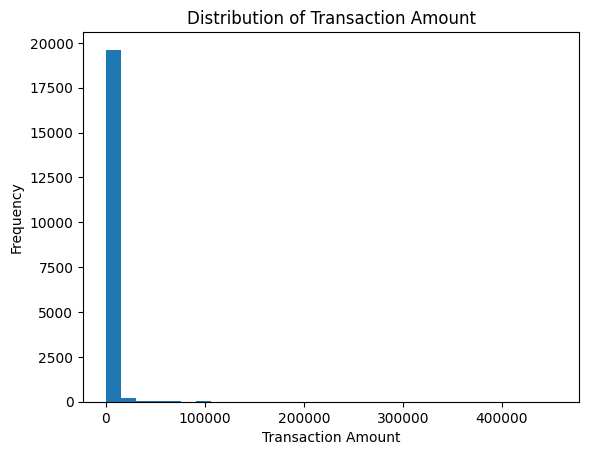

In [ ]:

plt.hist(data["TransactionAmount"], bins=30)
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amount")
plt.show()

  TransactionMonth  TransactionAmount
0           August         1341176.47
1          October         7404176.25
2        September        25610518.51


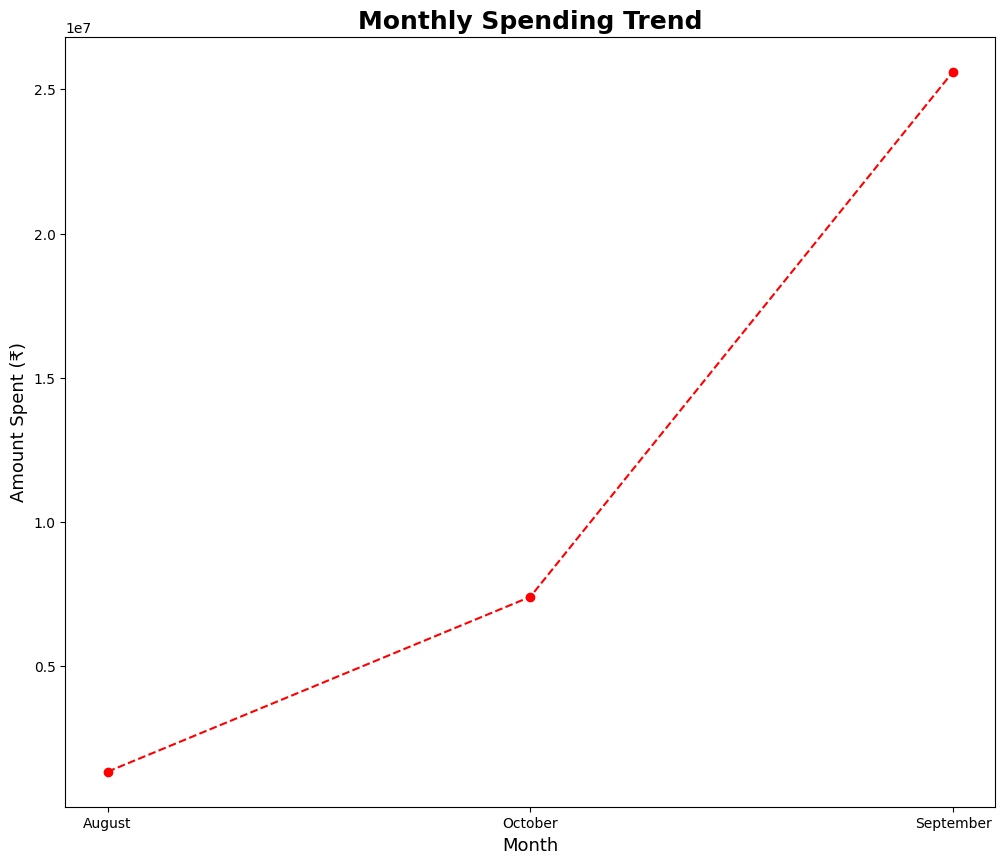

In [ ]:
Monthly_Spending = data.groupby('TransactionMonth')['TransactionAmount'].sum().reset_index()

print(Monthly_Spending)
plt.figure(figsize=(12,10))
plt.plot(
    Monthly_Spending['TransactionMonth'],
    Monthly_Spending['TransactionAmount'],
    color = 'red',
    marker = 'o',
    linestyle = '--'
)
plt.title("Monthly Spending Trend", fontsize=18, fontweight='bold')
plt.xlabel("Month", fontsize=13)
plt.ylabel("Amount Spent (₹)", fontsize=13)

plt.xticks(rotation=0)
plt.show()

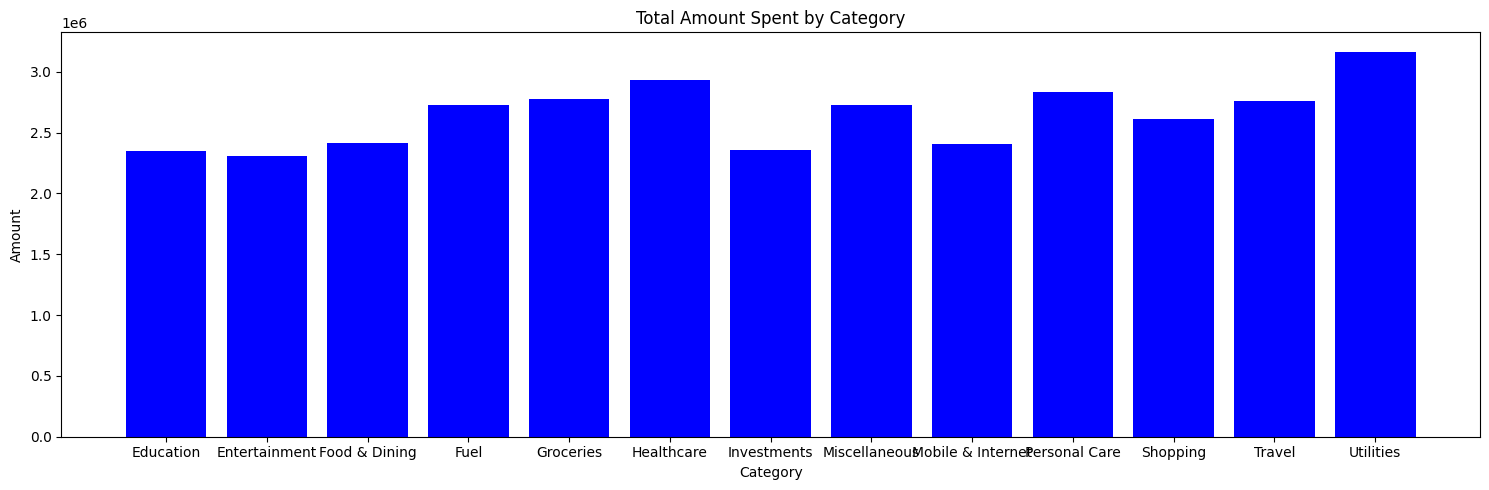

In [ ]:
category_spending = data.groupby('Category')['TransactionAmount'].sum().reset_index()
category_spending
plt.figure(figsize=(15,5))

plt.bar(
    category_spending['Category'],
    category_spending['TransactionAmount'],
    color = 'blue'
)

plt.title("Total Amount Spent by Category")
plt.xlabel("Category")
plt.ylabel("Amount")

plt.tight_layout()
plt.show()

    EventDate  TransactionAmount
0           1           32403.99
1           2           47633.61
2           3           41260.17
3           4           26512.04
4           5           40385.83
5           6           32548.83
6           7          254126.99
7           8           31729.00
8           9           27464.24
9          10           28813.15
10         11           91082.25
11         12           22844.51
12         13           17831.47
13         14           22321.05
14         15          100335.89
15         16           22202.92
16         17            3664.75
17         18           15661.00
18         19           52968.98
19         20          120718.35
20         21         7509314.46
21         22         5230304.81
22         23          536593.47
23         24           44276.54
24         25         4669369.20
25         26        11948391.18
26         27         3315751.11
27         28           10696.60
28         29           24897.73
29        

<Axes: xlabel='EventDate', ylabel='TransactionAmount'>

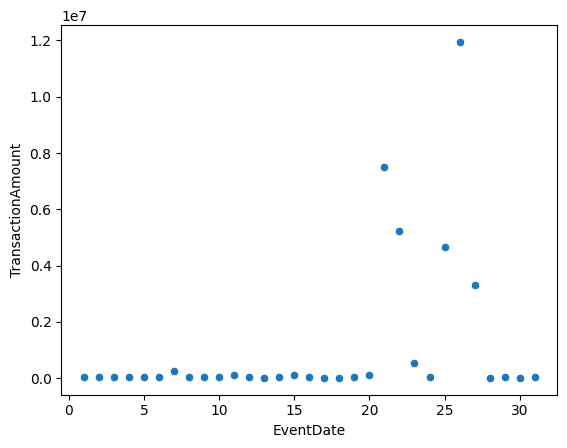

In [ ]:
daily_Spending = data.groupby('EventDate')['TransactionAmount'].sum().reset_index()

print(daily_Spending)

sns.scatterplot(x = 'EventDate' , y = 'TransactionAmount', data = daily_Spending)

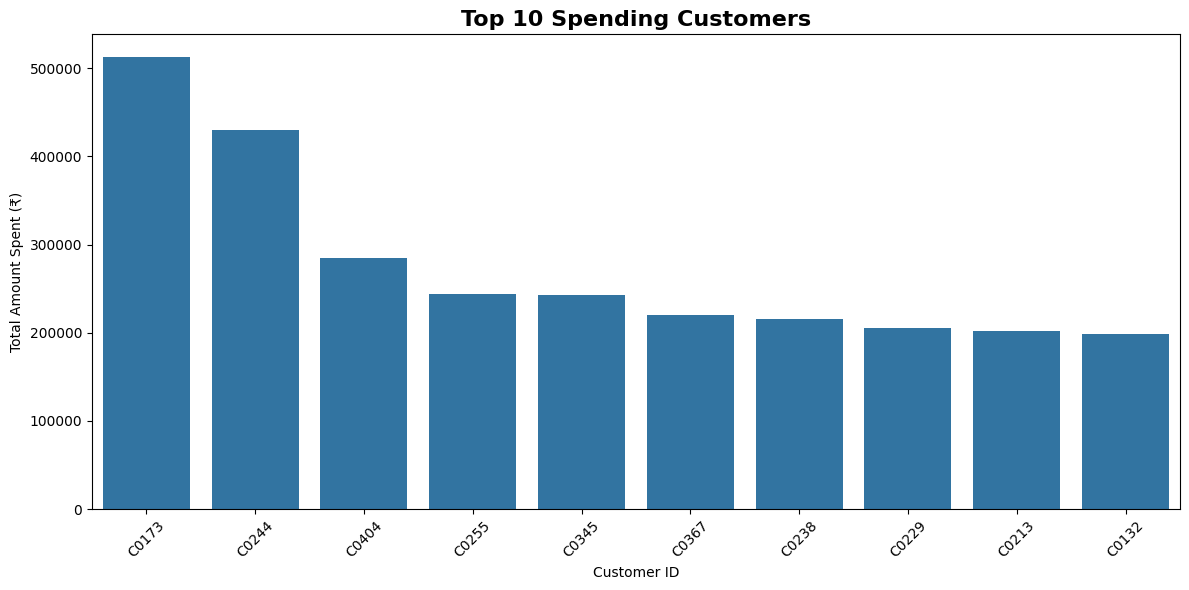

In [ ]:
top_customers = (
    data.groupby("CustomerID")["TransactionAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_customers,
    x="CustomerID",
    y="TransactionAmount"
)

plt.title("Top 10 Spending Customers", fontsize=16, fontweight="bold")
plt.xlabel("Customer ID")
plt.ylabel("Total Amount Spent (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

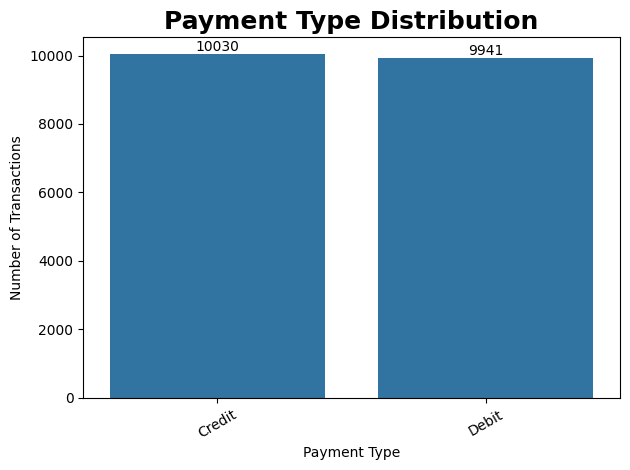

In [ ]:
ax = sns.countplot(
    data = data,
    x = "PaymentType",
    order = data['PaymentType'].value_counts().index
)
plt.title("Payment Type Distribution", fontsize=18, weight="bold")
plt.xlabel("Payment Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30)

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


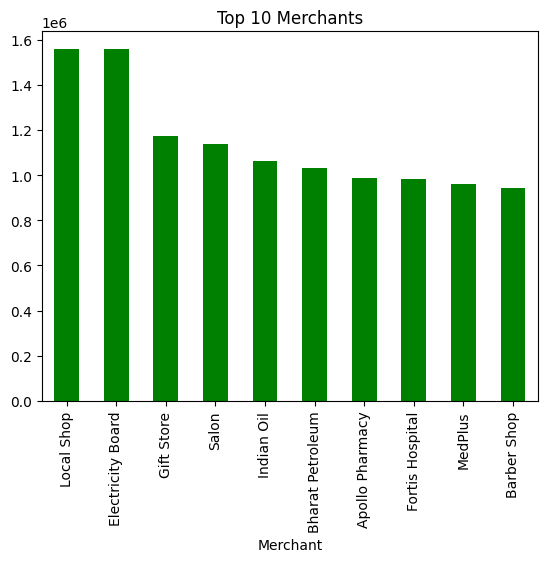

In [ ]:
merchant = data.groupby("Merchant")["TransactionAmount"].sum().sort_values(ascending=False)

merchant.head(10).plot(kind="bar", color = "green")
plt.title("Top 10 Merchants")
plt.show()

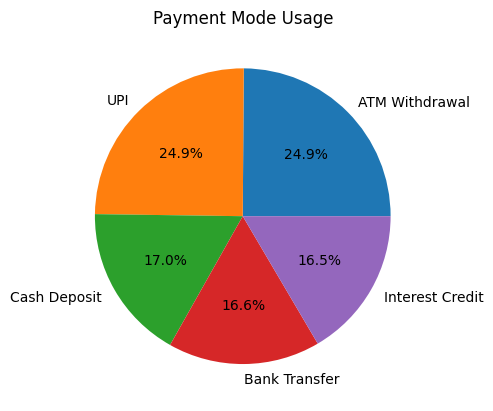

In [ ]:
#Payment Mode Usage
data["PaymentMode"].value_counts().plot(kind = "pie", autopct="%1.1f%%")
plt.ylabel('')
plt.title("Payment Mode Usage")
plt.show()

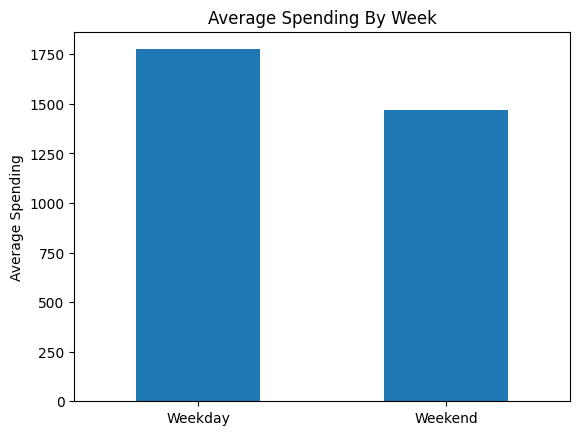

In [ ]:
week = data.groupby("IsWeekend")["TransactionAmount"].mean()

week.index = ["Weekday", "Weekend"]

week.plot(kind="bar")
plt.ylabel("Average Spending")
plt.xticks(rotation = 0)
plt.title("Average Spending By Week")
plt.show()

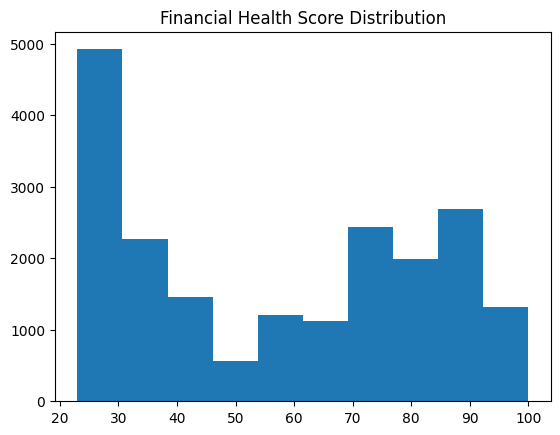

In [ ]:
plt.hist(data["HealthScore"])
plt.title("Financial Health Score Distribution")
plt.show()

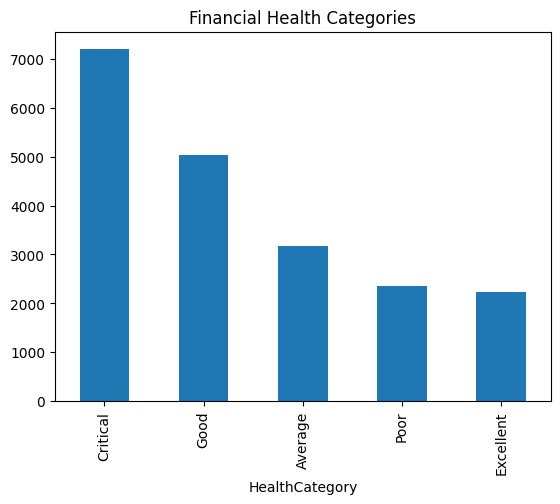

In [ ]:
data["HealthCategory"].value_counts().plot(kind="bar")
plt.title("Financial Health Categories")
plt.show()

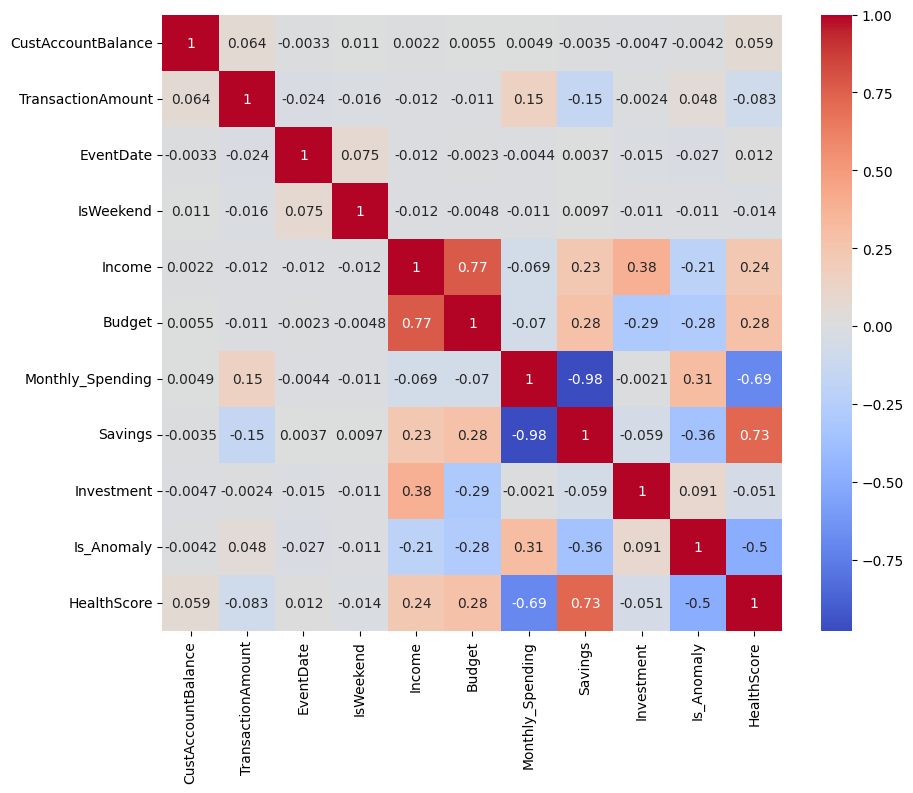

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

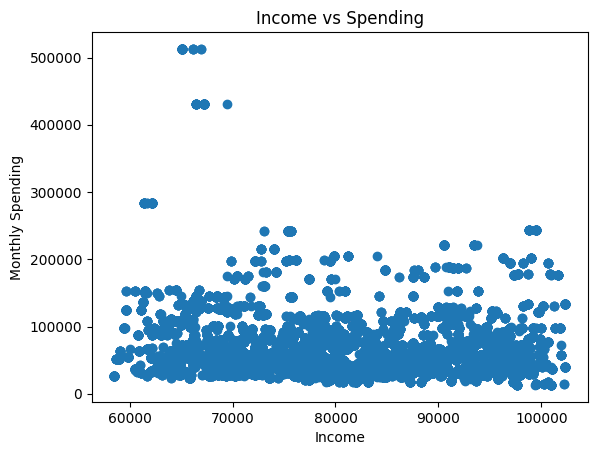

In [ ]:
plt.scatter(data["Income"], data["Monthly_Spending"])

plt.xlabel("Income")
plt.ylabel("Monthly Spending")
plt.title("Income vs Spending")
plt.show()

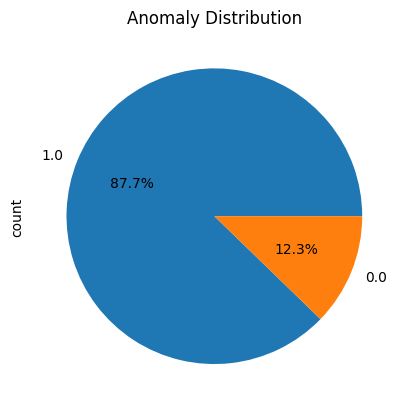

In [ ]:
data["Is_Anomaly"].value_counts().plot(kind = 'pie', autopct="%1.1f%%")

plt.title("Anomaly Distribution")
plt.show()

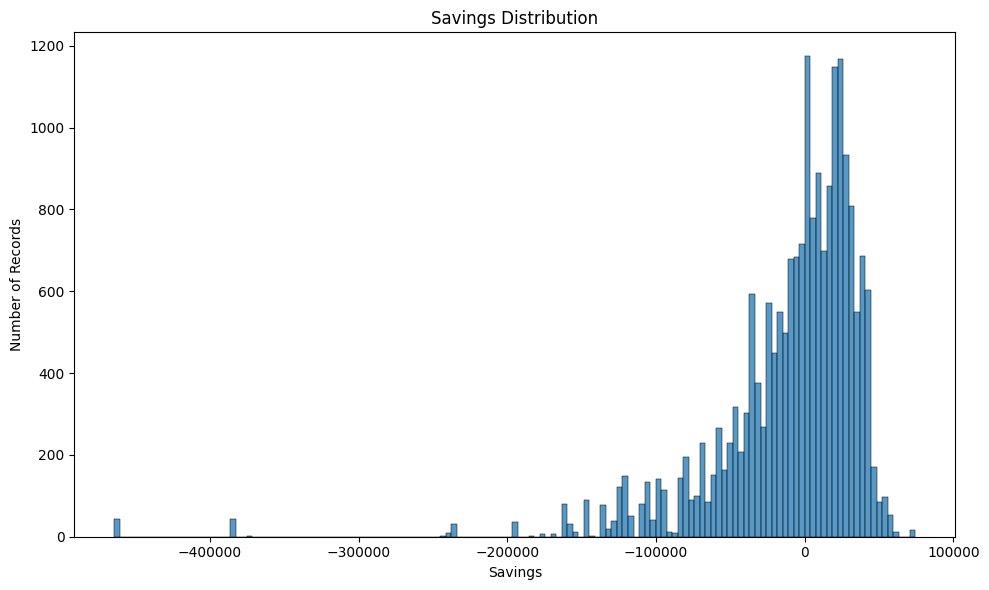

In [ ]:

plt.figure(figsize=(10,6))

sns.histplot(
    data["Savings"],
)

plt.title("Savings Distribution")
plt.xlabel("Savings")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

====Model Performance====
Logistic:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       491
         1.0       1.00      1.00      1.00      3504

    accuracy                           1.00      3995
   macro avg       1.00      1.00      1.00      3995
weighted avg       1.00      1.00      1.00      3995

Decision Tree:
               precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       491
         1.0       1.00      1.00      1.00      3504

    accuracy                           1.00      3995
   macro avg       1.00      0.99      1.00      3995
weighted avg       1.00      1.00      1.00      3995

Ridge:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       491
         1.0       0.88      1.00      0.93      3504

    accuracy                           0.88      3995
   macro avg       0.44      0.50      0.47      3995
weighted avg 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


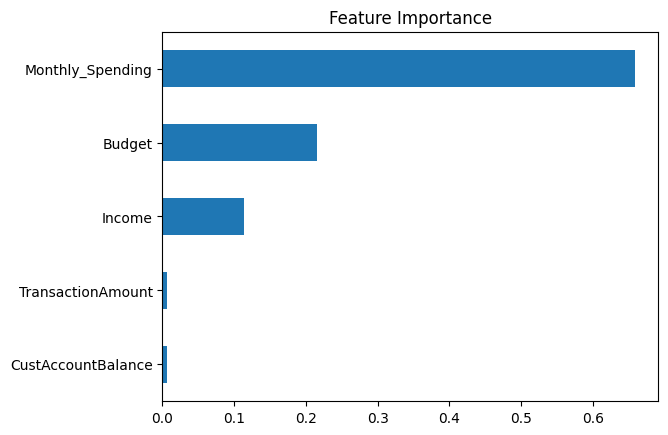

In [ ]:
X = data[[
    "Income",
    "Budget",
    "TransactionAmount",
    "CustAccountBalance",
    "Monthly_Spending"
]]

y = data["Is_Anomaly"]

X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model_Logistic = LogisticRegression()
model_Logistic.fit(X_train,y_train)
lr = model_Logistic.predict(X_test)

model_Ridge = RidgeClassifier(alpha = 1.0)
model_Ridge.fit(X_train,y_train)
rg = model_Ridge.predict(X_test)

model_DecisonTree = DecisionTreeRegressor()
model_DecisonTree.fit(X_train,y_train)
dt = model_DecisonTree.predict(X_test)

model_random = RandomForestClassifier(random_state=42)
model_random.fit(X_train, y_train)
rf = model_random.predict(X_test)

print("====Model Performance====")
print("Logistic:\n", classification_report(y_test, lr))
print("Decision Tree:\n", classification_report(y_test, dt))
print("Ridge:\n",classification_report(y_test, rg))
print("Random Forest:\n", classification_report(y_test, rf))

print("====Model Performance====")
print("Logistic: ",accuracy_score(y_test, lr))
print("Decision Tree: ",accuracy_score(y_test, dt))
print("Ridge:", accuracy_score(y_test,rg))
print("Random Forest:", accuracy_score(y_test, rf))

importance = pd.Series(
    model_random.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


====Model Performance====
Logistic:
               precision    recall  f1-score   support

          23       0.14      0.01      0.01       155
          25       0.70      0.93      0.80       727
          28       0.00      0.00      0.00        34
          30       0.49      0.29      0.37        78
          33       0.00      0.00      0.00        77
          35       0.36      0.60      0.45       370
          38       0.00      0.00      0.00        32
          40       0.57      0.58      0.57       113
          43       0.00      0.00      0.00        25
          45       0.49      0.38      0.43       137
          48       0.00      0.00      0.00        19
          50       0.35      0.21      0.26        82
          53       0.00      0.00      0.00         4
          55       0.00      0.00      0.00        33
          58       0.00      0.00      0.00        26
          60       0.11      0.06      0.08       155
          63       0.00      0.00      0.00 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

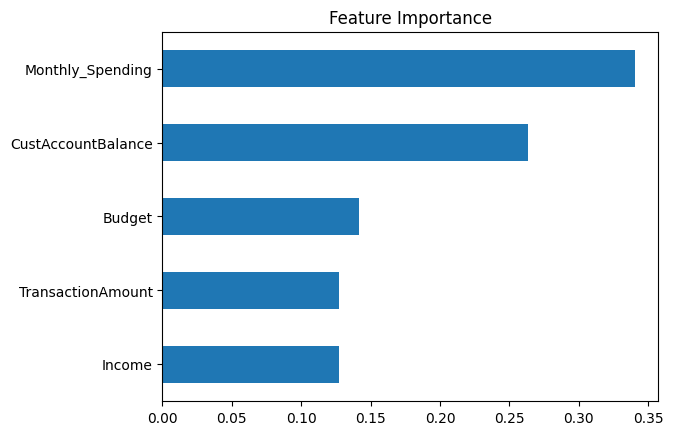

In [ ]:
X = data[[
    "Income",
    "Budget",
    "TransactionAmount",
    "CustAccountBalance",
    "Monthly_Spending"
]]

y = data["HealthScore"]

X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model_Logistic = LogisticRegression()
model_Logistic.fit(X_train,y_train)
lr = model_Logistic.predict(X_test)

model_Ridge = RidgeClassifier(alpha = 1.0)
model_Ridge.fit(X_train,y_train)
rg = model_Ridge.predict(X_test)

model_DecisonTree = DecisionTreeRegressor()
model_DecisonTree.fit(X_train,y_train)
dt = model_DecisonTree.predict(X_test)

model_random = RandomForestClassifier(random_state=42)
model_random.fit(X_train, y_train)
rf = model_random.predict(X_test)

print("====Model Performance====")
print("Logistic:\n", classification_report(y_test, lr))
print("Decision Tree:\n", classification_report(y_test, dt))
print("Ridge:\n",classification_report(y_test, rg))
print("Random Forest:\n", classification_report(y_test, rf))

print("====Model Performance====")
print("Logistic: ",accuracy_score(y_test, lr))
print("Decision Tree: ",accuracy_score(y_test, dt))
print("Ridge:", accuracy_score(y_test,rg))
print("Random Forest:", accuracy_score(y_test, rf))

importance = pd.Series(
    model_random.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

<Axes: xlabel='Income', ylabel='TransactionAmount'>

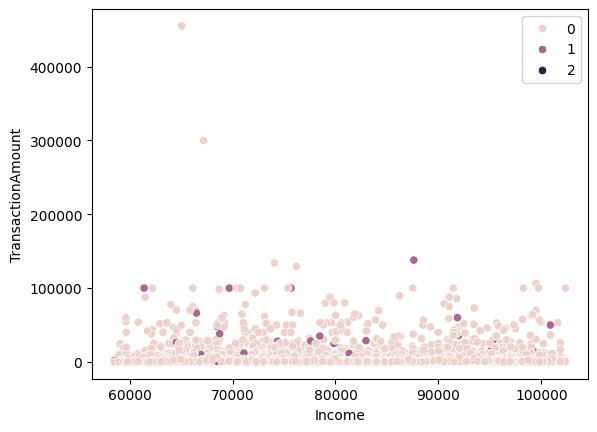

In [ ]:
model_kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

cluster = model_kmeans.fit_predict(X)

sns.scatterplot(data=data,x="Income",y="TransactionAmount",hue=Cluster)